# Day 3: Machine Learning from Data to Evaluation

We will build a binary classifier for Titanic survival. The notebook uses only pandas, NumPy, and Matplotlib, making every step visible and avoiding an extra machine-learning dependency. Run all cells from a fresh kernel.

## 1. Frame the problem

The target `survived` is binary: 1 means survived and 0 means did not survive. Features are information available about each passenger. We will keep a test set untouched during training so evaluation measures performance on unseen rows.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TITANIC_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
titanic = pd.read_csv(TITANIC_URL)
titanic.columns = titanic.columns.str.lower()
print(titanic.shape)
titanic.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Prepare features

We choose six numeric or easily encoded features. `sex` is encoded as 0/1. Missing values will be filled only after the split, using medians learned from the training rows.

In [2]:
feature_names = ["pclass", "sex", "age", "sibsp", "parch", "fare"]
model_data = titanic[feature_names + ["survived"]].copy()
model_data["sex"] = model_data["sex"].map({"male": 0, "female": 1})

print(model_data.isna().sum())
model_data.head()

pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
survived      0
dtype: int64


,pclass,sex,age,sibsp,parch,fare,survived
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,1
3,1,1,35.0,1,0,53.1000,1
4,3,0,35.0,0,0,8.0500,0


## 3. Create reproducible train and test sets

A fixed random seed makes the split reproducible. Eighty percent of rows train the model; twenty percent evaluate it.

In [3]:
rng = np.random.default_rng(42)
indices = rng.permutation(len(model_data))
split_at = int(0.8 * len(indices))
train_indices, test_indices = indices[:split_at], indices[split_at:]

train_data = model_data.iloc[train_indices].copy()
test_data = model_data.iloc[test_indices].copy()
fill_values = train_data[["age", "fare"]].median()
train_data[["age", "fare"]] = train_data[["age", "fare"]].fillna(fill_values)
test_data[["age", "fare"]] = test_data[["age", "fare"]].fillna(fill_values)

X_train_raw = train_data[feature_names].to_numpy(dtype=float)
X_test_raw = test_data[feature_names].to_numpy(dtype=float)
y_train = train_data["survived"].to_numpy(dtype=float)
y_test = test_data["survived"].to_numpy(dtype=float)
assert not np.isnan(X_train_raw).any() and not np.isnan(X_test_raw).any()
print(f"Training rows: {len(y_train)}; test rows: {len(y_test)}")

Training rows: 712; test rows: 179


Standardization puts features on comparable scales. The mean and standard deviation come only from the training set, preventing test-set information from leaking into training.

In [4]:
train_mean = X_train_raw.mean(axis=0)
train_std = X_train_raw.std(axis=0)
train_std = np.where(train_std == 0, 1.0, train_std)
X_train = (X_train_raw - train_mean) / train_std
X_test = (X_test_raw - train_mean) / train_std

assert np.allclose(X_train.mean(axis=0), 0.0, atol=1e-10)
print(pd.DataFrame(X_train, columns=feature_names).describe().loc[["mean", "std"]].round(3))

      pclass    sex    age  sibsp  parch   fare
mean  -0.000  0.000  0.000  0.000  0.000  0.000
std    1.001  1.001  1.001  1.001  1.001  1.001


## 4. Train logistic regression

Logistic regression converts a weighted sum into a probability with the sigmoid function. Gradient descent repeatedly adjusts the weights to reduce binary cross-entropy loss.

In [5]:
def sigmoid(values):
    clipped = np.clip(values, -500, 500)
    return 1.0 / (1.0 + np.exp(-clipped))

def binary_cross_entropy(actual, probability):
    safe_probability = np.clip(probability, 1e-12, 1 - 1e-12)
    return -np.mean(actual * np.log(safe_probability) + (1 - actual) * np.log(1 - safe_probability))

assert np.isclose(sigmoid(np.array([0.0]))[0], 0.5)
assert binary_cross_entropy(np.array([1.0]), np.array([0.9])) < binary_cross_entropy(np.array([1.0]), np.array([0.6]))

In [6]:
weights = np.zeros(X_train.shape[1])
bias = 0.0
learning_rate = 0.1
loss_history = []

for step in range(2000):
    train_probability = sigmoid(X_train @ weights + bias)
    error = train_probability - y_train
    weights = weights - learning_rate * (X_train.T @ error) / len(y_train)
    bias = bias - learning_rate * error.mean()
    if step % 100 == 0:
        loss_history.append(binary_cross_entropy(y_train, train_probability))

print(f"Initial loss: {loss_history[0]:.4f}")
print(f"Final loss:   {loss_history[-1]:.4f}")
assert loss_history[-1] < loss_history[0]

Initial loss: 0.6931
Final loss:   0.4311


## 5. Predict and evaluate

A probability of at least 0.5 becomes class 1. Accuracy is useful here, but the confusion matrix shows which types of mistakes were made.

In [7]:
test_probability = sigmoid(X_test @ weights + bias)
predictions = (test_probability >= 0.5).astype(int)
accuracy = np.mean(predictions == y_test)
print(f"Test accuracy: {accuracy:.3f}")
print("First 10 probabilities:", np.round(test_probability[:10], 3))

Test accuracy: 0.743
First 10 probabilities: [0.569 0.101 0.917 0.136 0.665 0.665 0.045 0.07  0.101 0.251]


In [8]:
true_negative = int(np.sum((y_test == 0) & (predictions == 0)))
false_positive = int(np.sum((y_test == 0) & (predictions == 1)))
false_negative = int(np.sum((y_test == 1) & (predictions == 0)))
true_positive = int(np.sum((y_test == 1) & (predictions == 1)))
confusion = np.array([[true_negative, false_positive], [false_negative, true_positive]])
print(pd.DataFrame(confusion, index=["actual 0", "actual 1"], columns=["predicted 0", "predicted 1"]))

          predicted 0  predicted 1
actual 0           84           26
actual 1           20           49


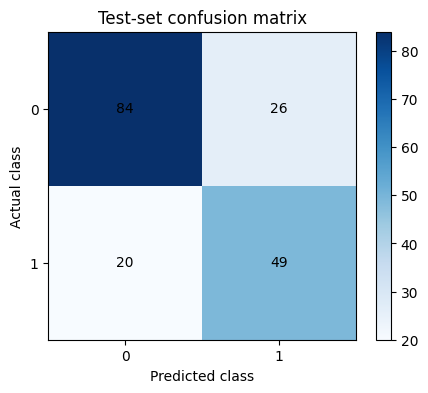

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(confusion, cmap="Blues")
for row in range(2):
    for column in range(2):
        ax.text(column, row, confusion[row, column], ha="center", va="center")
ax.set(xticks=[0, 1], yticks=[0, 1], xlabel="Predicted class", ylabel="Actual class", title="Test-set confusion matrix")
fig.colorbar(image, ax=ax)
plt.show()

Precision asks how often a positive prediction is correct. Recall asks how many actual positive cases are found. F1 balances the two.

In [10]:
precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)
f1 = 2 * precision * recall / (precision + recall)
metrics = pd.Series({"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1})
metrics.round(3)

accuracy     0.743
precision    0.653
recall       0.710
f1           0.681
dtype: float64

## 6. Interpret the model

Because features were standardized, coefficient magnitudes are comparable. Positive coefficients raise the predicted log-odds of survival; negative coefficients lower them. Association is not causation.

In [11]:
coefficient_table = (
    pd.DataFrame({"feature": feature_names, "coefficient": weights})
    .assign(absolute_coefficient=lambda table: table["coefficient"].abs())
    .sort_values("absolute_coefficient", ascending=False)
)
coefficient_table.round(3)

,feature,coefficient,absolute_coefficient
1,sex,1.364,1.364
0,pclass,-0.983,0.983
2,age,-0.640,0.640
3,sibsp,-0.488,0.488
5,fare,0.116,0.116
4,parch,-0.071,0.071


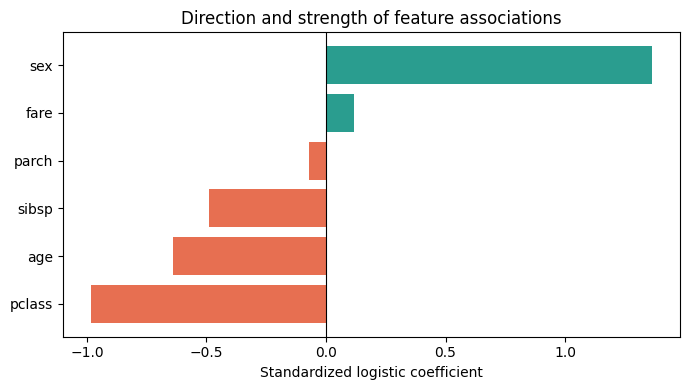

In [12]:
plot_table = coefficient_table.sort_values("coefficient")
colors = np.where(plot_table["coefficient"] >= 0, "#2a9d8f", "#e76f51")
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(plot_table["feature"], plot_table["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(xlabel="Standardized logistic coefficient", title="Direction and strength of feature associations")
plt.tight_layout()
plt.show()

## 7. Next steps

Try changing the decision threshold, adding `alone` or `embarked`, or comparing this model with a decision tree in an environment that includes a machine-learning library. Keep the test set untouched until the final comparison.